In [1]:
%matplotlib widget
from debye3d import Experiment, Debye3D
import numpy as np
import matplotlib.pyplot as plt
from utilities import *

## Define Experiment

In [3]:
wl = 1.54
distance = 0.36
npix = 1000
pix_size = 0.00015 # 150µum
exp = Experiment(wl=wl, distance=distance,npix=npix,pixel_size=pix_size)

----------------------------------------------------
 Detector configuration / accessible Q-range
----------------------------------------------------
 Wavelength λ = 1.5400 Å
 Sample-detector distance = 360.00 mm
 Pixel size = 0.150 mm
 Number of pixels = 1000 x 1000
 |Q| range : 0.0000 → 1.1650 Å⁻¹
----------------------------------------------------



## Case of spherical particles (isotropic case)

In the following, we consider spherical Au nanoparticles of about 3nm diameter, peridodically arranged as an fcc lattice of 3.5nm parameter. As an exercice, we will compute the SAXS image observed along the 11 zone axis of the paracrystal structure.

In real space, the structure can be ssen as the convolution of a single particle with a periodic fcc structure. We will there fore decompose our calculations as follow:
1. form factor computation $P(\vec{q})$ based on single particle calculation
2. Structure factor computation $S(\vec{q})$, based on crystal network computation

The total scattering, in reciprocal space, is therefore simply computed as
$$ I(\vec{q}) = P(\vec{q})*S(\vec{q})$$




### I. Form factor calculation

We will compare scattered intensities computed with the following methods:
- Debye 3D + detector frame integration with pyFAI
- Debye3Dd + orientational average
- Debye Caclulator (based on Debye scattering equation)
- analytic expression for the form factor of a sphere.

No significant difference is expected between these signals, as isotropic signal is expected.



1. Initialize Debye3D instance

In [7]:
def sphere_from_cif(
    cif_file,
    diameter,
    outputname,
    center='cell'
):
    """
    Create a spherical nanoparticle from a CIF file.

    Parameters
    ----------
    cif_file : str
        Path to CIF file.
    diameter : float
        Sphere diameter in Angstrom.
    center : str or array-like
        'cell'  -> center of unit cell
        'com'   -> center of mass
        array   -> explicit Cartesian coordinates

    Returns
    -------
    Atoms
        ASE Atoms object containing the spherical nanoparticle.
    """

    # 1. Read unit cell
    atoms = read(cif_file)

    # 2. Estimate supercell size
    cell_lengths = atoms.cell.lengths()
    max_a = max(cell_lengths)

    n_repeat = int(np.ceil(diameter / max_a)) + 2
    supercell = atoms.repeat((n_repeat, n_repeat, n_repeat))

    # 3. Choose center
    if center == 'cell':
        center_pos = supercell.cell.sum(axis=0) / 2
    elif center == 'com':
        center_pos = supercell.get_center_of_mass()
    else:
        center_pos = np.asarray(center)

    # 4. Cut sphere
    positions = supercell.get_positions()
    distances = np.linalg.norm(positions - center_pos, axis=1)
    mask = distances <= diameter / 2

    nanoparticle = supercell[mask]

    # 5. Recenter nanoparticle
    nanoparticle.translate(-nanoparticle.get_center_of_mass())
    # 6. Save to file
    nb_atoms = len(nanoparticle)
    with open(outputname, 'w') as f:
        f.write(f"{nb_atoms}\n\n")
        for atom in nanoparticle:
            symbol = atom.symbol
            x, y, z = atom.position
            f.write(f"{symbol}\t{x:.6f}\t{y:.6f}\t{z:.6f}\n")

    return nb_atoms, outputname

file = f'./structures/Au_radius=100A.xyz' # path to structure file
ciffile='/home-local/ratel-ra/Documents/CIF_database/Au_fixed.cif'
sphere_from_cif(ciffile,diameter=30,outputname=file)
d3d = Debye3D(file, distance= exp.distance, wl= exp.wl, npix= exp.npix, pixel_size= exp.pixel_size)
print(f'Structure contains {d3d.nb_atoms} atoms')


----------------------------------------------------
 Detector configuration / accessible Q-range
----------------------------------------------------
 Wavelength λ = 1.5400 Å
 Sample-detector distance = 360.00 mm
 Pixel size = 0.150 mm
 Number of pixels = 1000 x 1000
 |Q| range : 0.0000 → 1.1650 Å⁻¹
----------------------------------------------------


 Structure contains 887 atoms.

Structure contains 887 atoms


3. Compute intensity using DebyeCalculator (orientaional averaging)

In [8]:
q_dc, i_dc = d3d.compute_Iq_debyecalc()

4. Compute intesity projected on the detector frame (x,z) plane

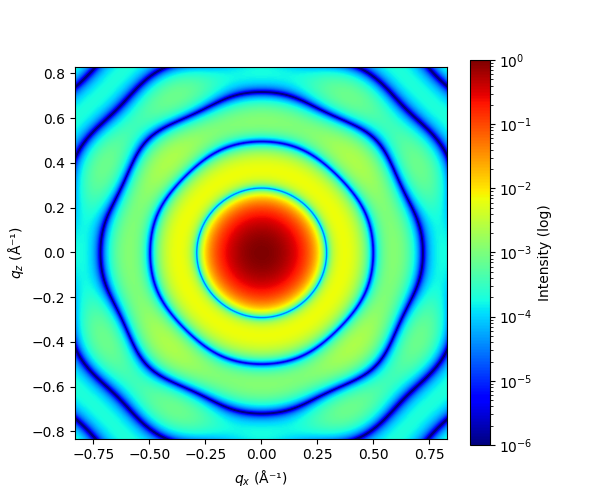

In [9]:
I_map=d3d.compute_intensity()
d3d.plot_intensity(I_map,vmin=-6)

5. Integrate detector frame with pyFAI

In [10]:
q,i = d3d.integrate_with_pyfai(I_map)


6. Compute orientational average

In [11]:
q_iso, i_iso = d3d.compute_isotropic_intensity_fibonacci()

→ Isotropic average (CPU) over orientations
-> Using adaptive Fibonacci algorithm (CPU) to compute orientation averaging


7. Compute analytic solution of spherical form factor



$I(q)= |N*f_0*F(q)|^2$ where $F(q)=3\frac{sin(qR)-qRcos(qR)}{(qR)^3}$

In [21]:
def saxs_sphere(q, R):
    qR = q * R
    # handle q=0 to avoid division by zero
    Fq = np.ones_like(qR)
    nonzero = qR != 0
    Fq[nonzero] = 3 * (np.sin(qR[nonzero]) - qR[nonzero] * np.cos(qR[nonzero])) / (qR[nonzero]**3)
    return Fq

def saxs_sphere_intensity(q, R):
    """
    Compute the SAXS intensity for a homogeneous sphere: I(q) = |f*F(q)|^2
    """
    Fq = saxs_sphere(q, R)
    return np.abs(Fq)**2*d3d.xray_f0(d3d.elements[0],q)**2*d3d.nb_atoms**2

q_th = np.linspace(d3d.q_min,d3d.q_max,500)
i_th=saxs_sphere_intensity(q_th,14.95)  # true radius of the sphere is 14.985 (not 15)

7. Plot results for comparison

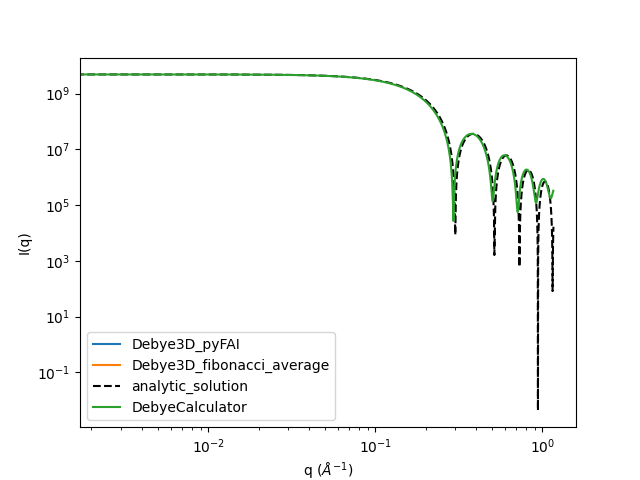

In [22]:
plt.figure()
mask = q > 2
mask2=q_iso >2
plt.loglog(q[mask],i[mask],label='Debye3D_pyFAI')
plt.loglog(q_iso[mask2],i_iso[mask2],label='Debye3D_fibonacci_average')
plt.loglog(q_th,i_th,'--k',label='analytic_solution')
plt.semilogy(q_dc, i_dc,label = 'DebyeCalculator')
plt.xlabel('q ($\AA^{-1}$)')
#plt.xlim(0.001,2)
plt.ylabel('I(q)')
plt.legend()

For memory, we save the number of atoms and f as variables, to be further used for structure factor computation


In [23]:
nb_atoms = d3d.nb_atoms
Z= d3d.xray_f0(d3d.elements[0],0) #= Z for simplicity

### II. Structure factor calculation

We wil use functions defined in generate_paracrystal_assembly to build supercelle of paracrystals.

In this example we will assume fcc lattice of spherical particles (SG #255) a=3.5nm,
We wil simulate a zone axis 110 obtained by  rotations of 45° around z axes.

1. Lattice generation

In [24]:
from generate_paracrystal_assembly import *
# fcc assembly, SG = Fm-3m #225 (a = 3.5nm)
structure_file = generate_supercell([35,35, 35, 90,90,90], spacegroup=225, supercell_size=(20,20,20))



Supermaille générée : supercell.xyz (32000 atomes)


2. Structure rotation to obtaine zone axis [111]

We will use the method rotate_positions implemented in Debye3D class.
By default the zone axis is 010. We therefore perform a single rotation of 45° each around z to get 110 zone axis.

In [ ]:
# initialization of Debye3D class
d3d = Debye3D(structure_file, distance= exp.distance, wl= exp.wl, npix= exp.npix, pixel_size= exp.pixel_size)
d3d.positions = d3d.rotate_positions(0,0,45)
#d3d.view_structure()

----------------------------------------------------
 Detector configuration / accessible Q-range
----------------------------------------------------
 Wavelength λ = 1.5400 Å
 Sample-detector distance = 360.00 mm
 Pixel size = 0.150 mm
 Number of pixels = 1000 x 1000
 |Q| range : 0.0000 → 1.1650 Å⁻¹
----------------------------------------------------


 Structure contains 32000 atoms.

426 translations loaded
548 translations loaded
splash_image=jar:file:/home-local/ratel-ra/jmol-16.3.15/Jmol.jar!/org/openscience/jmol/app/images/Jmol_splash.jpg
Jmol version 16.3.15  2025-04-10 22:21
User macros dir: /home-local/ratel-ra/.jmol/macros
       exists: false
  isDirectory: false
Executing script: load "file.xyz";


In [27]:
d3d.shake_positions(0.05,0.05,0.1)
#d3d.view_structure()

Reference length is 24.75


array([[-2.95258064e-01,  8.90227232e-01,  1.81132159e+00],
       [-1.15828567e+01,  1.31890077e+01,  1.92700983e+01],
       [ 1.22710418e+01,  1.23257776e+01,  1.91354446e+01],
       ...,
       [-1.25376542e+01,  9.51901333e+02,  6.84837346e+02],
       [ 1.30446299e+01,  9.53728714e+02,  6.83164409e+02],
       [ 8.09707731e-01,  9.64459769e+02,  6.62646652e+02]])

3. Compute structure factor

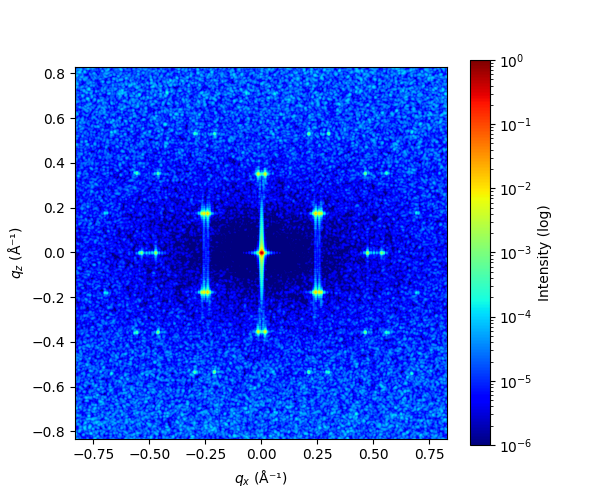

In [28]:

I_stru = d3d.compute_structure_factor(nb_atoms,Z)
d3d.plot_intensity(I_stru,vmin=-6)

### III. Computation of resulting SAXS image



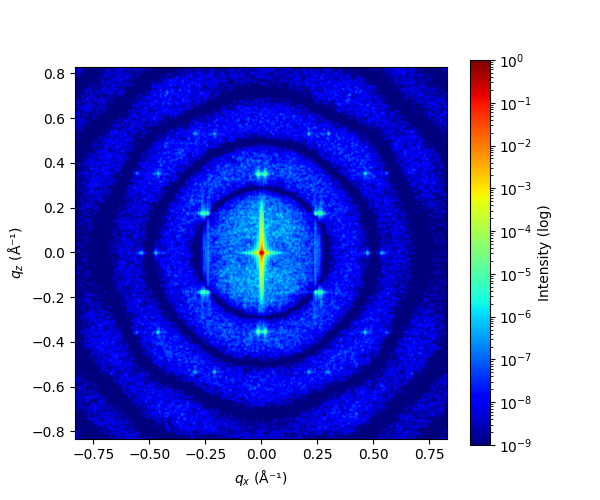

In [29]:

d3d.plot_intensity(I_map*I_stru,vmin=-9)